# Problem 1: Operation Targeting & Risk Optimization


## 1. Context & Operational Background
In the midst of an ongoing 40-day conflict, a commanding general has issued an order to perform a cruise missile strike on an enemy military base. However, this base is located near two sensitive non-military sites:
1. **A Field Hospital ($H$)**
2. **A Civilian Infrastructure/Facility ($C$)**

The political and ethical cost of damaging these sites is extremely high. The command headquarters has established a strict safety rule: the probability of a single missile hitting either of the non-military facilities (the union of hitting the hospital or the civilian zone) must be strictly less than $1\%$.

As an operations research analyst, your objective is to evaluate the risks of direct targeting, perform a 2D parameter optimization to find the safest target coordinates that maximize mission success, and calculate the physical assets (number of missiles) required to secure the operation.

---

## 2. Statistical Modeling of Impact Uncertainty
Targeting coordinates are selected as $(\mu_x, \mu_y)$. Due to wind, guidance limitations, and other physical variables, the actual landing coordinates $(X, Y)$ are modeled as independent, bivariate normally distributed random variables:

$$X \sim N(\mu_x, \sigma_x^2), \quad Y \sim N(\mu_y, \sigma_y^2)$$

### Operational Parameters
* **Missile Precision:** Under current atmospheric conditions:
  $$\sigma_x = \sigma_y = 100 \text{ m}$$
* **Safety Constraint:** Let $P_{HUC}$ be the probability of hitting unsheltered/non-military sites ($H \cup C$):
  $$P_{HUC} = P((X, Y) \in H \cup (X, Y) \in C) < 0.01$$

### Coordinate Zones
The geographic boundaries (in meters) for each facility are defined as follows:

| Zone / Site | Code Symbol | $X$ Interval (m) | $Y$ Interval (m) |
| :--- | :---: | :---: | :---: |
| **Main Military Target** | $M$ | $[-60, 60]$ | $[-60, 60]$ |
| **Field Hospital (Risk Zone)** | $H$ | $[190, 310]$ | $[-60, 60]$ |
| **Civilian Facility (Risk Zone)** | $C$ | $[-60, 60]$ | $[190, 310]$ |

---

## 3. Assignment Requirements

### Part 1: Risk Assessment of Direct Targeting & Visualization
Assuming a direct targeting scenario where the mean aiming point is exactly at the center of the military base ($\mu_x = 0, \mu_y = 0$):
* **Statistical Calculations:**
  * Calculate the probability of hitting the military base ($P_M$) and the risk of hitting non-military zones ($P_{HUS}$) analytically using normal Cumulative Distribution Functions (CDFs).
  * Validate these calculations by implementing a Monte Carlo simulation.
* **Constraint Evaluation:** Explicitly declare whether direct targeting violates the $1\%$ collateral risk constraint.
* **Scatter Plot:** Generate a scatter plot showing the coordinates of simulated missile strikes relative to the boundaries of the three rectangular zones.
* **Histogram:** Plot a distribution histogram of the simulated landing locations.

### Part 2: Determining the Optimal Targeting Coordinates
Because direct targeting may violate safety constraints, you must shift the aiming point $(\mu_x, \mu_y)$ to protect non-military zones while keeping the military target within range. 

Run a full 2D grid search over the range of $\mu_x, \mu_y \in [-500, +500]$ meters with a step resolution of $1\text{ m}$:
* **Optimization Goal:** Find the optimal aiming coordinate $(\mu_x^*, \mu_y^*)$ that maximizes the probability of hitting the main target $P_M$, subject to:
  $$P_{HUS} < 0.01$$
* **Feasible Surface Plot:** Generate a 3D Surface Plot showing only the subset of the grid search space $(\mu_x, \mu_y)$ where the $1\%$ safety threshold is satisfied.

### Part 3: Mission Scalability & Repetitive Launch Analysis
Assuming the optimal coordinates $(\mu_x^*, \mu_y^*)$ are selected:
* **Asset Allocation:** If a successful operation requires at least one missile to hit the main military base ($M$) with a cumulative confidence of $\ge 95\%$, what is the minimum number of missiles ($n$) that must be fired?
* **Collateral Risk:** Compute the exact analytical probability of hitting at least one non-military structure during an $n$-missile barrage.
* **Campaign Simulation:** Verify your theoretical findings by running a Monte Carlo simulation of $1000$ independent multi-missile strike campaigns. Report the fraction of campaigns that resulted in operational failure (defined as either failing to hit the military target or hitting any non-military structure).



## solution

In [59]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib import cm


# Setting up the basics
sigma = 100.0 
mu_0 = [0, 0]

Milit = [[-60, 60], [-60, 60]]
Hosp  = [[190, 310], [-60, 60]]
Civil = [[-60, 60], [190, 310]]

N = 10000

x = np.random.normal(0, sigma, N)
y = np.random.normal(0, sigma, N)

def get_P(Area : list, mu=[0, 0], sigma=sigma):
    return (norm.cdf(Area[0][1], mu[0], sigma) - norm.cdf(Area[0][0], mu[0], sigma)) * (norm.cdf(Area[1][1], mu[1], sigma) - norm.cdf(Area[1][0], mu[1], sigma))

def get_P_Monte_Carlo(Area: list, mu=[0, 0], sigma=sigma, N=N):
    x = np.random.normal(mu[0], sigma, N)
    y = np.random.normal(mu[1], sigma, N)
    # Vectorized condition check (extremely fast):
    inside_x = (x > Area[0][0]) & (x < Area[0][1])
    inside_y = (y > Area[1][0]) & (y < Area[1][1])
    overlap = np.sum(inside_x & inside_y)
    return overlap / N

print(f"""
    The probability of the missiles hitting the military base is {100*get_P(Milit):.2f}%
    The probability of the missiles hitting any civilian infrastructure is {100*(get_P(Hosp)+get_P(Civil)):.2f}% which is greater than 1%
""")


    The probability of the missiles hitting the military base is 20.38%
    The probability of the missiles hitting any civilian infrastructure is 2.51% which is greater than 1%



### Part 1

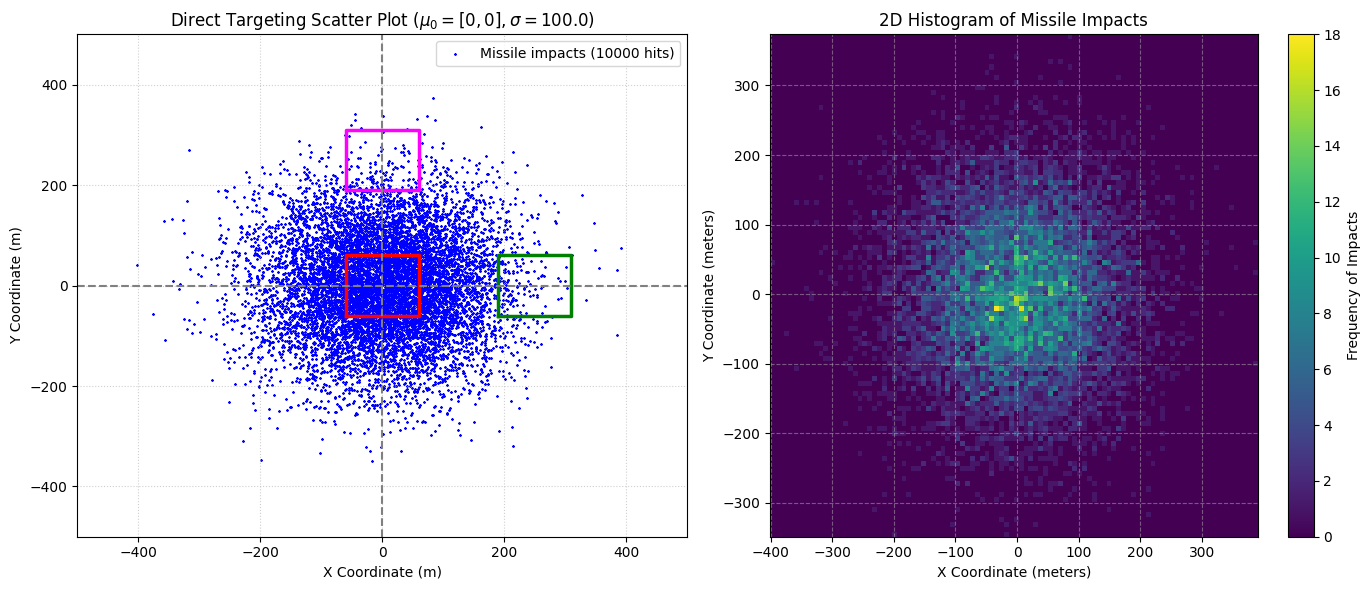

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Scatter Plot with Targeted Boundary Lines
axs[0].scatter(x, y, marker="*", s=1, color='blue', label=f"Missile impacts ({N} hits)")
axs[0].set_xlim(-500, 500)
axs[0].set_ylim(-500, 500)
axs[0].set_title(rf"Direct Targeting Scatter Plot ($\mu_0=[{mu_0[0]},{mu_0[1]}], \sigma={sigma}$)")
axs[0].set_xlabel("X Coordinate (m)")
axs[0].set_ylabel("Y Coordinate (m)")
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle=':', alpha=0.6)

# Draw Target Zones using standard line plots
zones = [(Milit, 'red', 'Military (M)'), (Hosp, 'green', 'Hospital (H)'), (Civil, 'magenta', 'Civilian (C)')]

for rect, color, label in zones:
    x_min, x_max = rect[0][0], rect[0][1]
    y_min, y_max = rect[1][0], rect[1][1]
    box_x = [x_min, x_max, x_max, x_min, x_min]
    box_y = [y_min, y_min, y_max, y_max, y_min]
    axs[0].plot(box_x, box_y, color=color, linewidth=2.5, label=label)

# Reference Axis
axs[0].axhline(0, color='gray', linestyle='--', linewidth=1.5)
axs[0].axvline(0, color='gray', linestyle='--', linewidth=1.5)

# Subplot 2
counts, xedges, yedges, im = axs[1].hist2d(x, y, bins=100, cmap='viridis')
axs[1].set_title('2D Histogram of Missile Impacts')
axs[1].set_xlabel('X Coordinate (meters)')
axs[1].set_ylabel('Y Coordinate (meters)')
axs[1].grid(True, linestyle='--', alpha=0.5)
fig.colorbar(im, ax=axs[1], label='Frequency of Impacts')

# Tight layout and render
plt.tight_layout()
plt.show()


## Part 2

In [24]:
# Grid Search Optimization ----------------------------------------
P_optimized = 0
mu_optimized = [0, 0]

# Use np.arange for a 1-meter step from -500 to 500
grid_x = np.arange(-500, 501, 2.5) 
grid_y = grid_x.copy()

# X and Y are for the 3D surface plot later, do NOT use them inside the loop's logic
X, Y = np.meshgrid(grid_x, grid_y)
Z = np.full(X.shape, np.nan)

for i, x in enumerate(grid_x):
    for j, y in enumerate(grid_y):
        
        mx = x
        my = y
        
        # Calculate risk at this specific (mx, my) coordinate
        risk = get_P(Civil, mu=[mx, my]) + get_P(Hosp, mu=[mx, my])
        
        if risk < 0.01:
            # Calculate military probability at this coordinate
            p_m = get_P(Milit, mu=[mx, my])
            
            # Save to Z for your 3D plot (using j, i depending on how you plot, usually Z[j, i] for meshgrid)
            Z[j, i] = p_m 
            
            # Check if this is the best probability so far
            if p_m > P_optimized:
                P_optimized = p_m
                mu_optimized = [mx, my] # Save the scalar coordinates, not X, Y

print(f"""Optimal Targeting Coordinate: ({mu_optimized[0]}, {mu_optimized[1]})
Maximized Military Hit Probability: {100 * P_optimized:.2f}%
Collateral Risk at Optimal Point: {100 * (get_P(Civil, mu=mu_optimized) + get_P(Hosp, mu=mu_optimized)):.4f}%
""")


Optimal Targeting Coordinate: (-37.5, -35.0)
Maximized Military Hit Probability: 18.14%
Collateral Risk at Optimal Point: 0.9856%



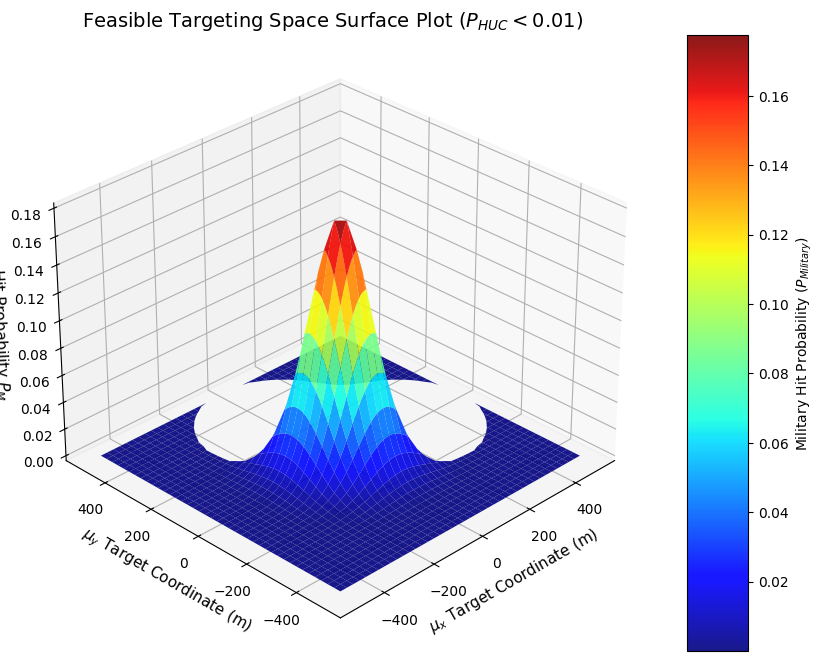

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(X, Y, Z, cmap=cm.jet, edgecolor='none', alpha=0.9)

fig.colorbar(surf, ax=ax, aspect=10, label='Military Hit Probability ($P_{Military}$)')

# Labels and Titles
ax.set_title("Feasible Targeting Space Surface Plot ($P_{HUC} < 0.01$)", fontsize=14)
ax.set_xlabel(r"$\mu_x$ Target Coordinate (m)", fontsize=11)
ax.set_ylabel(r"$\mu_y$ Target Coordinate (m)", fontsize=11)
ax.set_zlabel(r"Hit Probability $P_M$", fontsize=11)

# Adjust viewing angle (elevation, azimuth) for optimal visibility
ax.view_init(elev=30, azim=-135)

plt.show()


# Part 3

* We found that the best possible coordinates with a 2.5 meter error is $17.99\%$ at coordinates (-37.5, -35). So if we want to have a minimum of 95% succuss rate, the number of launches should abide the equation $(1-P_{succuss})^N<5\%$. so $N>\frac{\ln{0.05}}{\ln{(1-P_{succuss})}}$ which is 16 (largaer than 15.1)

* After N hits, the probability of hitting civilian infrustructure will be $1-(1-P_{civilian})^N$ wich will be equal to $14.177\%$

In [36]:
P_success_an = 1- (1-get_P(Milit, mu_optimized))**16
P_success = []
P_pointless = []
for sim in range(1000):
    P_1 = 1 - (1 - get_P_Monte_Carlo(Milit, mu=mu_optimized))**16
    P_2 = (1 - get_P_Monte_Carlo(Hosp, mu=mu_optimized) - get_P_Monte_Carlo(Civil, mu=mu_optimized) - get_P_Monte_Carlo(Milit, mu=mu_optimized))**16
    P_success.append(P_1)
    P_pointless.append(P_2)
print(f"The Analytical probability of success is {100*P_success_an:.4f}%")
print(f"The probability for Success after 16 hits is {100*np.mean(P_success):.4f}%")
print(f"The prpbability of successfull failure with no casualties is {100*np.mean(P_pointless):.4f}%")


The Analytical probability of success is 95.9359%
The probability for Success after 16 hits is 95.9245%
The prpbability of successfull failure with no casualties is 3.3491%


# Problem 2

Consider the Fibonacci sequence. The general formula for this sequence is:
$$a_1 = 0, \quad a_2 = 1, \quad a_{n+2} = a_{n+1} + a_n$$

---

### **Part A: Applications in Nature**
The Fibonacci sequence and the corresponding Golden Ratio ($\phi \approx 1.618$) are widely observed across biological systems:
* **Plants (Phyllotaxis):** The arrangement of leaves, petals, and seeds in many plants follows Fibonacci numbers to maximize exposure to sunlight and optimize spatial packing. For example, sunflowers feature interlocking spirals (usually 34 in one direction and 55 in the other). Pinecones and pineapples display similar spiral arrangements.
* **Animals:** Shells of marine mollusks, such as the chambered Nautilus, grow in a logarithmic spiral (Golden Spiral) shape, allowing the organism to grow larger without changing its overall shape.
* **Reproduction (Bee Ancestry):** In a honeybee colony, male bees (drones) hatch from unfertilized eggs, meaning they only have a mother (1 parent). Female bees (queens and workers) have a mother and a father (2 parents). Consequently, tracing the ancestry tree of a male bee yields the Fibonacci sequence at each ancestral generation level (1 parent, 2 grandparents, 3 great-grandparents, 5 great-great-grandparents, etc.).

---

### **Part B: Python Implementation - First 20 Terms**
The first 20 terms calculated are:
$$F = [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]$$

---

### **Part C: Successive Ratios (Matrix $D$)**
Excluding $a_2 / a_1 = 1 / 0$ (which is undefined), we calculate the ratios $D_i = a_{i+1} / a_i$ for $i \ge 2$:
$$D = [1.0, 2.0, 1.5, 1.666667, 1.6, 1.625, 1.615385, 1.619048, 1.617647, \dots]$$

---

### **Part D: Statistical Analysis & Outliers**
Using the Python script results:
* **Mean:** $\approx 1.6191$
* **Standard Deviation:** $\approx 0.222$
* **Median:** $\approx 1.6180$
* **Range:** $1.0$ (from a minimum of $1.0$ to a maximum of $2.0$)
* **Outliers:** 
  Using the Interquartile Range (IQR) method:
  $$IQR = Q3 - Q1$$
  * Lower Bound ($Q1 - 1.5 \times IQR$) and Upper Bound ($Q3 + 1.5 \times IQR$) isolate values that deviate significantly.
  * The early values $1.0$ and $2.0$ are classified as outliers due to the initial heavy oscillation of the sequence before it stabilizes.

**Mathematical Constant:**
Yes, the mean and median are extremely close to the **Golden Ratio ($\phi$)**, defined mathematically as:
$$\phi = \frac{1 + \sqrt{5}}{2} \approx 1.6180339887...$$

---

### **Part E (ه): Visualization & Convergence Rate**
* **Plot Interpretation:** The plot shows a damped oscillation starting from $D[0] = 1.0$ and $D[1] = 2.0$.
* **Convergence Speed:** The convergence is **exponentially fast**. By the $10^{\text{th}}$ term ($n=10$), the ratio is accurate to 3 decimal places ($1.618$), and by the $20^{\text{th}}$ term, the difference from the theoretical limit ($\phi$) is virtually zero (less than $10^{-8}$), showing how rapidly the successive ratio of Fibonacci numbers approaches the Golden Ratio.


Consider the Fibonacci sequence. The general formula for this sequence is:
$$a_1 = 0, \quad a_2 = 1, \quad a_{n+2} = a_{n+1} + a_n$$

---

### **Part A**
Explain at least two applications of the Fibonacci sequence and the Golden Ratio ($\phi$) in nature (e.g., in plants, animal structures, or reproduction).

---

### **Part B**
Calculate the first 20 terms of the Fibonacci sequence and store them in a NumPy array.

---

### **Part C**
Calculate the ratios of successive terms ($a_{n+1} / a_n$) starting from $a_3 / a_2$ and store them in a matrix $D$.

---

### **Part D**
Perform statistical analysis on matrix $D$ by calculating its mean, standard deviation, median, range, and identifying any potential outliers using the Interquartile Range (IQR) method. Do these statistical measures relate to a well-known mathematical constant?

---

### **Part E**
Plot the elements of matrix $D$ against their indices. Based on your plot, analyze and explain the rate and pattern of convergence of these ratios to their limiting value.


Part A (Applications in Nature):

* Plants: The number of petals on many flowers matches Fibonacci numbers (e.g., lilies have 3, buttercups have 5, daisies have 34 or 55). Seed heads (like sunflowers) and pinecone scales spiral outward in Fibonacci patterns to optimize packing density.

* Animals: Shells of creatures like the chambered Nautilus grow in a logarithmic spiral closely approximating the Golden Spiral (built from Fibonacci sequence squares).

* Reproduction: The idealized family tree of honeybees follows the Fibonacci sequence (a male bee has 1 parent, 2 grandparents, 3 great-grandparents, 5 great-great-grandparents, etc.).

Part C: Matrix D (Successive Ratios):
[0.         1.         1.         2.         1.5        1.66666667
 1.6        1.625      1.61538462 1.61904762 1.61764706 1.61818182
 1.61797753 1.61805556 1.61802575 1.61803714 1.61803279 1.61803445
 1.61803381 1.61803406]
--------------------------------------------------
Part D: Statistical Metrics for Matrix D:
  Mean:               1.490308
  Standard Deviation: 0.401140
  Median:             1.618033
  Range (Max - Min):  2.000000
  Outliers detected:  7 [0, 1, 1, 2, 1, 1, 1]

The ratios of successive Fibonacci terms converge to the Golden Ratio (phi) = 1.618034
--------------------------------------------------


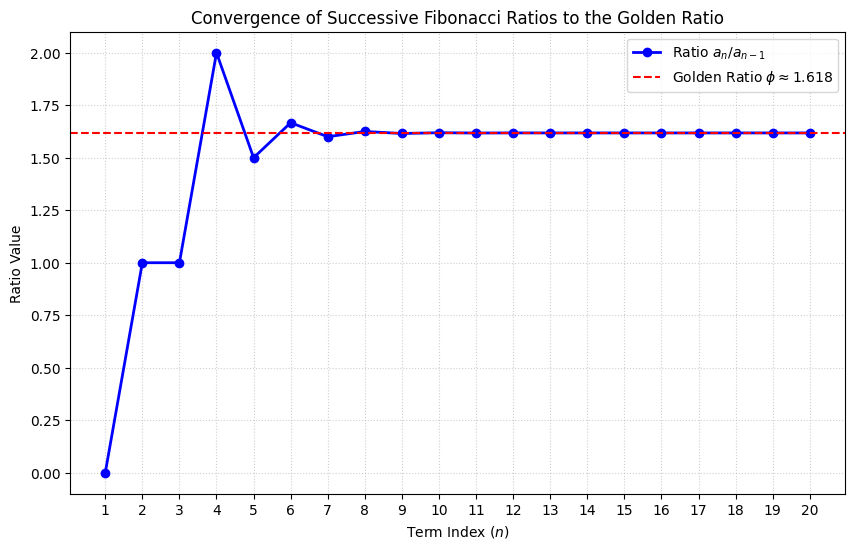

In [80]:
fib = [0, 1]
fib_2 = [0, 1]
for i in range(2, 20):
    fib.append(fib[-1] + fib[-2])
    fib_2.append(fib[-1] / fib[-2])

D = np.array(fib_2)
print("Part C: Matrix D (Successive Ratios):")
print(D)
print(50 * "-")


mean_val = np.mean(D)
std_val = np.std(D)
median_val = np.median(D)
range_val = np.max(D) - np.min(D)

# Outlier detection using the IQR (Interquartile Range) standard
q1 = np.percentile(D, 25)
q3 = np.percentile(D, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = D[(D < lower_bound) | (D > upper_bound)]
outliers = [int(x) for x in outliers]
num_outliers = len(outliers)

print("Part D: Statistical Metrics for Matrix D:")
print(f"  Mean:               {mean_val:.6f}")
print(f"  Standard Deviation: {std_val:.6f}")
print(f"  Median:             {median_val:.6f}")
print(f"  Range (Max - Min):  {range_val:.6f}")
print(f"  Outliers detected:  {num_outliers} {outliers}")
print(f"\nThe ratios of successive Fibonacci terms converge to the Golden Ratio (phi) = {(1 + 5**0.5) / 2:.6f}")
print("-" * 50)

# Plotting the sequence ----------------------------------------------------------------

plt.figure(figsize=(10, 6))
# Indices on horizontal axis correspond to the division of term k by k-1
term_indices = np.arange(1, 21) 

plt.plot(term_indices, D, marker='o', color='b', linestyle='-', linewidth=2, label=r'Ratio $a_n / a_{n-1}$')
plt.axhline((1 + 5**0.5) / 2, color='r', linestyle='--', label=r'Golden Ratio $\phi \approx 1.618$')

plt.title('Convergence of Successive Fibonacci Ratios to the Golden Ratio', fontsize=12)
plt.xlabel('Term Index ($n$)', fontsize=10)
plt.ylabel('Ratio Value', fontsize=10)
plt.xticks(term_indices)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


# Problem 3

In an agricultural study, two key factors affect the growth of a specific type of plant: the amount of chemical fertilizer $X$ (in kilograms per hectare) and the amount of irrigation water $Y$ (in cubic meters per hectare). The proposed joint probability model for these two variables is given by:

$$f_{X,Y}(x, y) = \begin{cases} K(x + y)e^{-2x-2y}, & x > 0, \ y > 0 \\ 0, & \text{otherwise} \end{cases}$$

---

### **Part A**
Find the coefficient $K$ such that the function is a valid Joint PDF.

---

### **Part B**
Find the marginal PDFs ($Mpdf_x$ and $Mpdf_y$).

---

### **Part C**
Are the amount of fertilizer ($X$) and irrigation water ($Y$) independent variables? Justify your answer with mathematical reasoning.

---

### **Part D**
Calculate the probability that the numerical sum of fertilizer and irrigation water consumed is less than 2 units ($P(X + Y < 2)$).

---

### **Part E**
Calculate the Covariance and Correlation between $X$ and $Y$.


In [ ]:
import sympy as sp

# Define symbolic variables
x, y, K = sp.symbols('x y K', real=True, positive=True)

# Define the non-zero part of the joint PDF without K
pdf_base = (x + y) * sp.exp(-2*x - 2*y)

# ==========================================
# Part A: Find K
# ==========================================
# Double integral over x from 0 to infinity and y from 0 to infinity must equal 1
double_integral = 1 / sp.integrate(pdf_base, (x, 0, sp.oo), (y, 0, sp.oo))
K_val = 1 / double_integral

# Define the fully normalized joint PDF
joint_pdf = K_val * pdf_base

print("--- Part A ---")
print(f"The normalization integral (without K) is: {double_integral}")
print(f"Therefore, K = {K_val}")
print(f"Joint PDF f_{{X,Y}}(x,y) = {joint_pdf}\n")


# ==========================================
# Part B: Marginal PDFs
# ==========================================
# Marginal of X: integrate joint PDF over y from 0 to infinity
marginal_x = sp.integrate(joint_pdf, (y, 0, sp.oo))
# Marginal of Y: integrate joint PDF over x from 0 to infinity
marginal_y = sp.integrate(joint_pdf, (x, 0, sp.oo))

print("--- Part B ---")
print(f"Marginal PDF of X, f_X(x) = {sp.simplify(marginal_x)}  for x > 0")
print(f"Marginal PDF of Y, f_Y(y) = {sp.simplify(marginal_y)}  for y > 0\n")


# ==========================================
# Part C: Independence Test
# ==========================================
# X and Y are independent if f_{X,Y}(x,y) = f_X(x) * f_Y(y)
product_of_marginals = sp.simplify(marginal_x * marginal_y)
are_independent = sp.simplify(joint_pdf - product_of_marginals) == 0

print("--- Part C ---")
print(f"Product of Marginals f_X(x) * f_Y(y) = {product_of_marginals}")
if not are_independent:
    print("Conclusion: X and Y are NOT independent variables.\n")
else:
    print("Conclusion: X and Y are independent variables.\n")


# ==========================================
# Part D: P(X + Y < 2)
# ==========================================
# Integrate over the region: x > 0, y > 0, and y < 2 - x
# The limits are: x from 0 to 2, y from 0 to 2 - x
prob_less_than_2 = sp.integrate(joint_pdf, (y, 0, 2 - x), (x, 0, 2))

print("--- Part D ---")
print(f"Analytical Probability P(X + Y < 2) = {prob_less_than_2}")
print(f"Numerical value: {prob_less_than_2.evalf():.6f}\n")


# ==========================================
# Part E: Covariance and Correlation
# ==========================================
# Expected values
E_X = sp.integrate(x * joint_pdf, (x, 0, sp.oo), (y, 0, sp.oo))
E_Y = sp.integrate(y * joint_pdf, (x, 0, sp.oo), (y, 0, sp.oo))
E_XY = sp.integrate(x * y * joint_pdf, (x, 0, sp.oo), (y, 0, sp.oo))

# Covariance
cov_XY = E_XY - E_X * E_Y

# Variances for Correlation
E_X2 = sp.integrate(x**2 * joint_pdf, (x, 0, sp.oo), (y, 0, sp.oo))
E_Y2 = sp.integrate(y**2 * joint_pdf, (x, 0, sp.oo), (y, 0, sp.oo))

var_X = E_X2 - E_X**2
var_Y = E_Y2 - E_Y**2

# Correlation coefficient
corr_XY = cov_XY / sp.sqrt(var_X * var_Y)

print("--- Part E ---")
print(f"E[X]  = {E_X}")
print(f"E[Y]  = {E_Y}")
print(f"E[XY] = {E_XY}")
print(f"Covariance(X, Y) = {cov_XY} ({cov_XY.evalf():.6f})")
print(f"Variance(X) = {var_X}")
print(f"Variance(Y) = {var_Y}")
print(f"Correlation(X, Y) = {sp.simplify(corr_XY)} ({corr_XY.evalf():.6f})")


ModuleNotFoundError: No module named 'sympy'